<h2>Data Pre-Processing & EDA<h2>

In [158]:
import pandas as pd

price_data = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/final_project/tesla_stock_data.csv")
sentiment_data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/final_project/merged_sentiment_scores.csv')

Inspect datasets

In [159]:
price_data.head()

,Date,Close,High,Low,Open,Volume
0,NaN,TSLA,TSLA,TSLA,TSLA,TSLA
1,2022-02-01,310.4166564941406,314.5666809082031,301.6666564941406,311.7366638183594,73138200
2,2022-02-02,301.88665771484375,310.5,296.4700012207031,309.3933410644531,66792900
3,2022-02-03,297.0466613769531,312.3333435058594,293.50665283203125,294.0,78855600
4,2022-02-04,307.7733459472656,312.1666564941406,293.72332763671875,299.0733337402344,73625400


In [160]:
price_data.tail()

,Date,Close,High,Low,Open,Volume
767,2025-02-21,337.79998779296875,354.9800109863281,334.4200134277344,353.44000244140625,74058600
768,2025-02-24,330.5299987792969,342.3999938964844,324.70001220703125,338.1400146484375,76052300
769,2025-02-25,302.79998779296875,328.8900146484375,297.25,327.0199890136719,134228800
770,2025-02-26,290.79998779296875,309.0,288.0400085449219,303.7099914550781,100118300
771,2025-02-27,281.95001220703125,297.2300109863281,280.8800048828125,291.1600036621094,101748200


In [161]:
sentiment_data.head()

,date,sentiment_score
0,2022-02-01,0.191575
1,2022-02-02,0.142081
2,2022-02-03,-0.011418
3,2022-02-04,-0.115670
4,2022-02-05,0.884207


In [162]:
sentiment_data.tail()

,date,sentiment_score
1117,2025-02-23,-0.005597
1118,2025-02-24,-0.327209
1119,2025-02-25,-0.428753
1120,2025-02-26,-0.122641
1121,2025-02-27,0.102019


The first row of the price_data should be removed.

In [163]:
price_data = price_data.drop(index=0)

As discussed in the sentimental analysis, some days had zero scores due to the lack of news articles on those days. These days are replaced with the average scores from the previous and next days.

In [164]:
# check how many days have zero score
zero_rows_count = (sentiment_data == 0).any(axis=1).sum()
print(f'Number of days with zero scores: {zero_rows_count}')

Number of days with zero scores: 34


In [165]:
# replace those days with average value of the previous and the next days
def replace_zeros_with_average(dataset, column_name):
  for i in range(1, len(dataset) - 1):
    if dataset.loc[i, column_name] == 0:
      dataset.loc[i, column_name] = (dataset.loc[i-1, column_name] + dataset.loc[i+1, column_name]) / 2

replace_zeros_with_average(sentiment_data, 'sentiment_score')

In [166]:
# check it again
zero_rows_count = (sentiment_data == 0).any(axis=1).sum()
print(f'Number of days with zero scores: {zero_rows_count}')

Number of days with zero scores: 0


Inspect more in both dataset:

In [167]:
print(price_data.info())
print(sentiment_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 771 entries, 1 to 771
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Date    771 non-null    object
 1   Close   771 non-null    object
 2   High    771 non-null    object
 3   Low     771 non-null    object
 4   Open    771 non-null    object
 5   Volume  771 non-null    object
dtypes: object(6)
memory usage: 36.3+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1122 entries, 0 to 1121
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   date             1122 non-null   object 
 1   sentiment_score  1122 non-null   float64
dtypes: float64(1), object(1)
memory usage: 17.7+ KB
None


To merge these 2 datasets, the name of date column in price_data ('Date') should be converted to 'date' (same as sentiment_data).</br>
Also, the date column in both datasets should be converted into datetime format.

In [168]:
price_data.rename(columns={'Date': 'date'}, inplace=True)
sentiment_data['date'] = pd.to_datetime(sentiment_data['date'])
price_data['date'] = pd.to_datetime(price_data['date'])

In [169]:
final_data = pd.merge(price_data, sentiment_data, on='date', how='inner')

Inspect the head and the tail of the merged dateset:

In [170]:
final_data.head()

,date,Close,High,Low,Open,Volume,sentiment_score
0,2022-02-01,310.4166564941406,314.5666809082031,301.6666564941406,311.7366638183594,73138200,0.191575
1,2022-02-02,301.88665771484375,310.5,296.4700012207031,309.3933410644531,66792900,0.142081
2,2022-02-03,297.0466613769531,312.3333435058594,293.50665283203125,294.0,78855600,-0.011418
3,2022-02-04,307.7733459472656,312.1666564941406,293.72332763671875,299.0733337402344,73625400,-0.115670
4,2022-02-07,302.4466552734375,315.92333984375,300.9033203125,307.92999267578125,60994500,-0.126334


In [171]:
final_data.tail()

,date,Close,High,Low,Open,Volume,sentiment_score
765,2025-02-21,337.79998779296875,354.9800109863281,334.4200134277344,353.44000244140625,74058600,-0.052371
766,2025-02-24,330.5299987792969,342.3999938964844,324.70001220703125,338.1400146484375,76052300,-0.327209
767,2025-02-25,302.79998779296875,328.8900146484375,297.25,327.0199890136719,134228800,-0.428753
768,2025-02-26,290.79998779296875,309.0,288.0400085449219,303.7099914550781,100118300,-0.122641
769,2025-02-27,281.95001220703125,297.2300109863281,280.8800048828125,291.1600036621094,101748200,0.102019


As we can see, the merger was successful.</br>
Some columns are in object format, while they should be in float64 format. So, they are converted.

In [172]:
final_data[['Close', 'High', 'Low', 'Open', 'Volume']] = final_data[['Close', 'High', 'Low', 'Open', 'Volume']].astype(float)
final_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 770 entries, 0 to 769
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   date             770 non-null    datetime64[ns]
 1   Close            770 non-null    float64       
 2   High             770 non-null    float64       
 3   Low              770 non-null    float64       
 4   Open             770 non-null    float64       
 5   Volume           770 non-null    float64       
 6   sentiment_score  770 non-null    float64       
dtypes: datetime64[ns](1), float64(6)
memory usage: 42.2 KB


In [173]:
# save the final dataset
# final_data.to_csv('/content/drive/MyDrive/Colab Notebooks/final_project/final_dataset.csv')

<h3>Outlier Detection<h3>

Outlier detection is done by the IQR method. Sentiment Score column does not need outlier detection because they are already in range of -1 to 1.

In [174]:
import numpy as np

selected_columns = ['Close', 'High', 'Low', 'Open', 'Volume']

# function to detect outliers by IQR
def IQR_method(dataset, column_name):
  Q1 = dataset[column_name].quantile(0.25)
  Q3 = dataset[column_name].quantile(0.75)
  IQR = Q3 - Q1 # find the range
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR
  outliers = dataset[(dataset[column_name] < lower_bound) | (dataset[column_name] > upper_bound)]
  return outliers

# find outliers
IQR_outliers = {col: IQR_method(final_data, col) for col in selected_columns}

for column in selected_columns:
  print("column: ", column)
  print('number of outliers detected: ', len(IQR_outliers[column]), '\n')

column:  Close
number of outliers detected:  29 

column:  High
number of outliers detected:  30 

column:  Low
number of outliers detected:  27 

column:  Open
number of outliers detected:  26 

column:  Volume
number of outliers detected:  27 



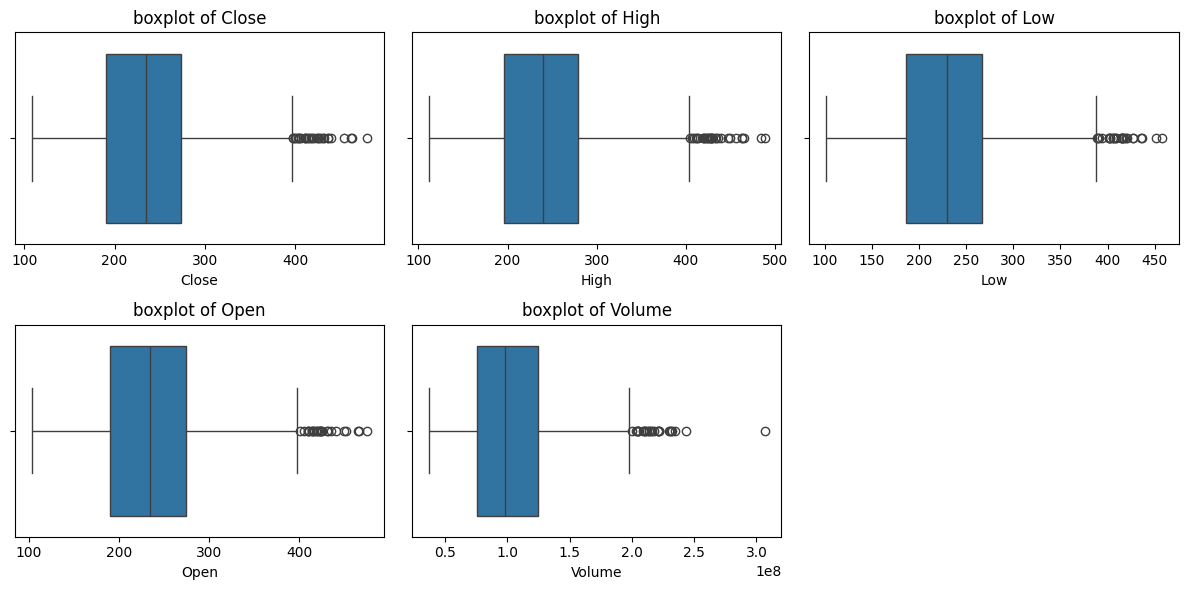

In [175]:
# plot outliers
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
for i, column in enumerate(selected_columns, 1):
  plt.subplot(2, 3, i)
  sns.boxplot(x=final_data[column])
  plt.title(f'boxplot of {column}')
plt.tight_layout()
plt.show()

There are some outliers is each column but I decided to keep them as they might have a valuable financial meaning rather than an error in data.

Inspect the summary statistics:

In [176]:
final_data.describe()

,date,Close,High,Low,Open,Volume,sentiment_score
count,770,770.000000,770.000000,770.000000,770.000000,7.700000e+02,770.000000
mean,2023-08-14 00:26:10.909090816,241.478515,247.093507,235.971671,241.736797,1.052512e+08,-0.055827
min,2022-02-01 00:00:00,108.099998,111.750000,101.809998,103.000000,3.716760e+07,-0.928341
25%,2022-11-04 18:00:00,190.999996,195.769997,186.032497,190.575005,7.610340e+07,-0.199639
50%,2023-08-14 12:00:00,235.260002,239.528336,230.221672,234.120003,9.797160e+07,-0.046830
75%,2024-05-19 06:00:00,273.245827,279.332512,266.924995,274.218330,1.249970e+08,0.095145
max,2025-02-27 00:00:00,479.859985,488.540009,457.510010,475.899994,3.065906e+08,0.643566
std,NaN,66.254905,68.072756,64.626087,66.620318,3.969691e+07,0.227593


Closing price (Target Variable) vs sentiment score

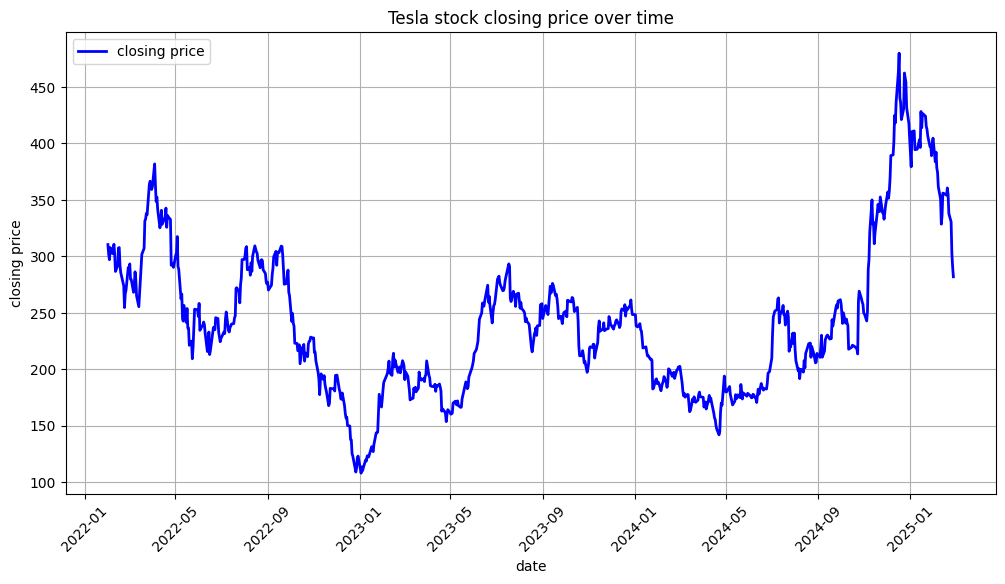

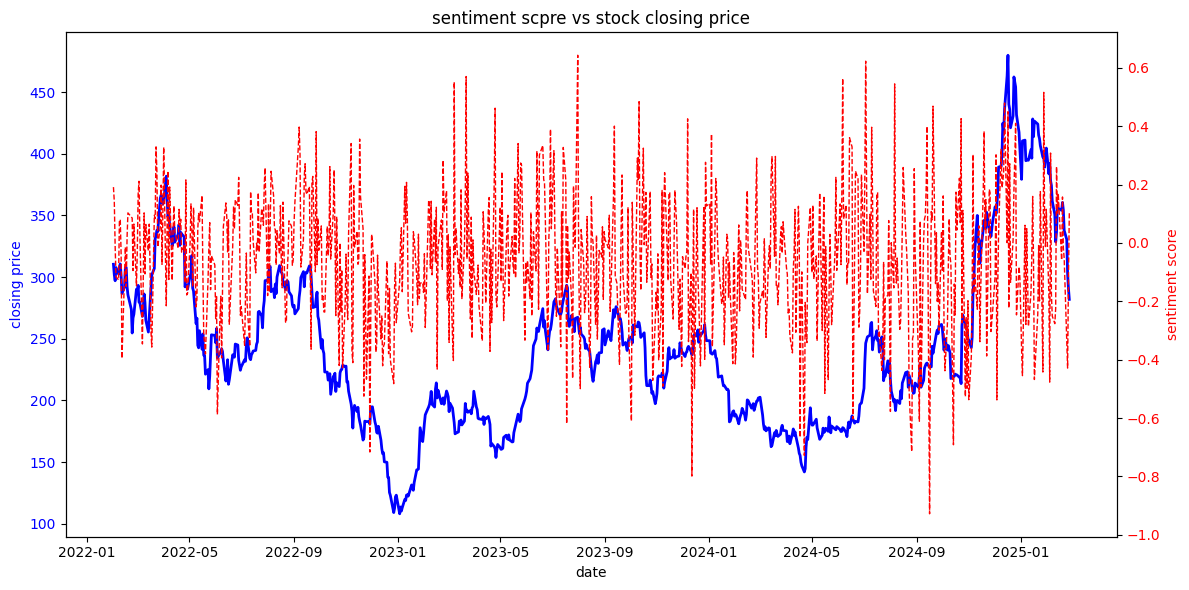

In [177]:
plt.figure(figsize=(12, 6))
plt.plot(final_data['date'], final_data['Close'], label='closing price', color='blue', linewidth=2)
plt.xlabel('date')
plt.ylabel('closing price')
plt.title('Tesla stock closing price over time')
plt.legend()
plt.xticks(rotation=45)
plt.grid()
plt.show()

# compare closing price with sentiment score
fig, ax_1 = plt.subplots(figsize=(12, 6))
ax_1.set_xlabel('date')
ax_1.set_ylabel('closing price', color='blue')
ax_1.plot(final_data['date'], final_data['Close'], label='closing price', color='blue', linewidth=2)
ax_1.tick_params(axis='y', labelcolor='blue')
ax_2 = ax_1.twinx()
ax_2.set_ylabel('sentiment score', color='red')
ax_2.plot(final_data['date'], final_data['sentiment_score'], label='sentiment score', color='red', linestyle='dashed', linewidth=1)
ax_2.tick_params(axis='y', labelcolor='red')
plt.title('sentiment scpre vs stock closing price')
fig.tight_layout()
plt.show()



*   Telsa's closing price has a strong volatility with multiple peaks and throughs.
*   There are some periods of steady growth and sharp declines, likely due to the market events, earning reports or macroeconomic factors.
*   A strong upward is in late 2024 and early 2025.
*   Sentiment scores are switching between positive and negative rapidly.
*   The score remains highly volatile throughout the period, which suggests frequent shifts in market sentiment based on news.
*   Negative sentiment may correlate with price drops, while positive score might support upward movements.
*   This suggests short term market reactions to green finance news but not necessarily long-term price impacts.



Correlation Analysis by Heatmaps

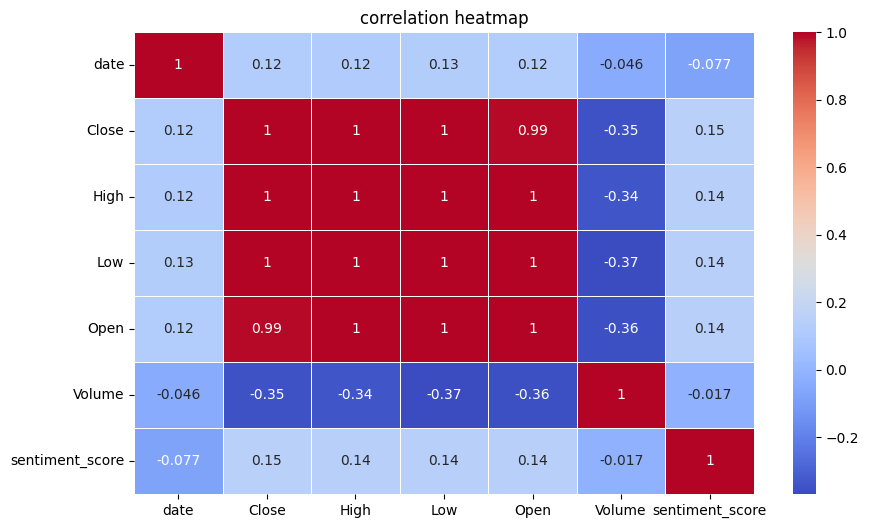

In [178]:
correlation_matrix = final_data.corr()
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('correlation heatmap')
plt.show()

The heatmap suggests that open, low and high are perfect predictors, while volume has a negative correlation with close, which is a good predictor.</br>
Sentiment score has a weak correlation with the close price; this could happen because it affects the closing price over time, and maybe other market factors have a larger impact.</br>
To see if sentiment affects prices after a delay, lagged sentiment analysis was performed in different lag periods (1, 3, 7 days).

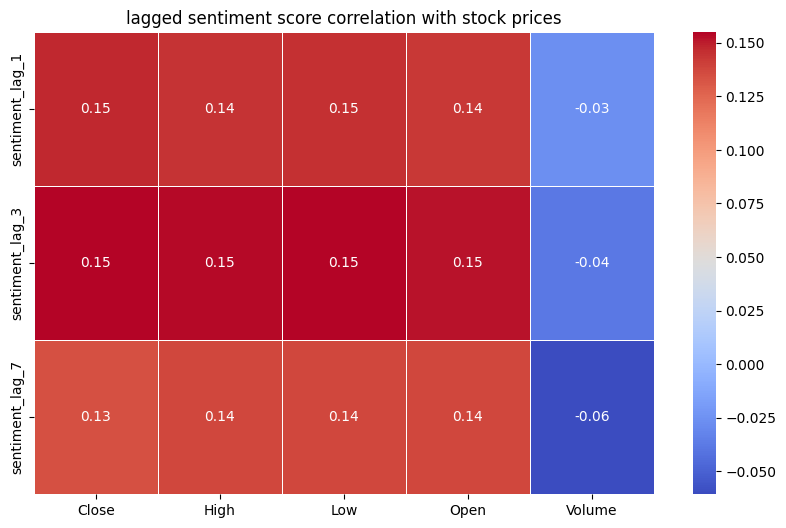

In [179]:
lags = [1, 3, 7]
for lag in lags:
    final_data[f'sentiment_lag_{lag}'] = final_data['sentiment_score'].shift(lag)


lagged_corr = final_data[['Close', 'High', 'Low', 'Open', 'Volume'] + [f'sentiment_lag_{lag}' for lag in lags]].corr()
sentiment_lag_corr = lagged_corr.loc[[f'sentiment_lag_{lag}' for lag in lags], ['Close', 'High', 'Low', 'Open', 'Volume']]

plt.figure(figsize=(10, 6))
sns.heatmap(sentiment_lag_corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("lagged sentiment score correlation with stock prices")
plt.show()

As we can see, the lagged sentiment scores do not significantly improve correlation with prices. So, they are removed from the dataset.

In [180]:
final_data = final_data.drop(columns=[f'sentiment_lag_{lag}' for lag in lags])

<h2>Feature Engineering for Sentiment Score<h2>

Daily sentiment scores fluctuate a lot, but what matters for stock prices is longer-term sentiment trends.

In [181]:
final_data['sentiment_rolling_7'] = final_data['sentiment_score'].rolling(window=7).mean()
final_data['sentiment_rolling_14'] = final_data['sentiment_score'].rolling(window=14).mean()
final_data['sentiment_rolling_30'] = final_data['sentiment_score'].rolling(window=30).mean()

If sentiment is highly volatile, it might signal uncertainty in the market. Markets dislike uncertainty, and high sentiment volatility might lead to price drops or sharp movements.

In [182]:
final_data['sentiment_volatility_7'] = final_data['sentiment_score'].rolling(window=7).std()
final_data['sentiment_volatility_14'] = final_data['sentiment_score'].rolling(window=14).std()

These new features are created based on a period of time, so all of them have missing values for a few first days. Based on the information below, filling NaN values with mean of each column is a good choice because the median and the mean are nearly same.

In [183]:
final_data.describe()

,date,Close,High,Low,Open,Volume,sentiment_score,sentiment_rolling_7,sentiment_rolling_14,sentiment_rolling_30,sentiment_volatility_7,sentiment_volatility_14
count,770,770.000000,770.000000,770.000000,770.000000,7.700000e+02,770.000000,764.000000,757.000000,741.000000,764.000000,757.000000
mean,2023-08-14 00:26:10.909090816,241.478515,247.093507,235.971671,241.736797,1.052512e+08,-0.055827,-0.055980,-0.056158,-0.056577,0.205983,0.214272
min,2022-02-01 00:00:00,108.099998,111.750000,101.809998,103.000000,3.716760e+07,-0.928341,-0.364670,-0.279075,-0.235802,0.049549,0.102001
25%,2022-11-04 18:00:00,190.999996,195.769997,186.032497,190.575005,7.610340e+07,-0.199639,-0.123603,-0.112280,-0.097905,0.153712,0.172305
50%,2023-08-14 12:00:00,235.260002,239.528336,230.221672,234.120003,9.797160e+07,-0.046830,-0.053945,-0.051008,-0.061338,0.197698,0.210088
75%,2024-05-19 06:00:00,273.245827,279.332512,266.924995,274.218330,1.249970e+08,0.095145,0.019018,-0.004770,-0.009621,0.252528,0.255318
max,2025-02-27 00:00:00,479.859985,488.540009,457.510010,475.899994,3.065906e+08,0.643566,0.271640,0.174966,0.072914,0.470588,0.395438
std,NaN,66.254905,68.072756,64.626087,66.620318,3.969691e+07,0.227593,0.106446,0.081701,0.061209,0.069731,0.054495


In [184]:
final_data['sentiment_rolling_7'] .fillna(final_data['sentiment_rolling_7'].mean(), inplace=True)
final_data['sentiment_rolling_14'].fillna(final_data['sentiment_rolling_14'].mean(), inplace=True)
final_data['sentiment_rolling_30'].fillna(final_data['sentiment_rolling_30'].mean(), inplace=True)
final_data['sentiment_volatility_7'].fillna(final_data['sentiment_volatility_7'].mean(), inplace=True)
final_data['sentiment_volatility_14'].fillna(final_data['sentiment_volatility_14'].mean(), inplace=True)

<ipython-input-184-04b9b54707ca>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  final_data['sentiment_rolling_7'] .fillna(final_data['sentiment_rolling_7'].mean(), inplace=True)
<ipython-input-184-04b9b54707ca>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when do

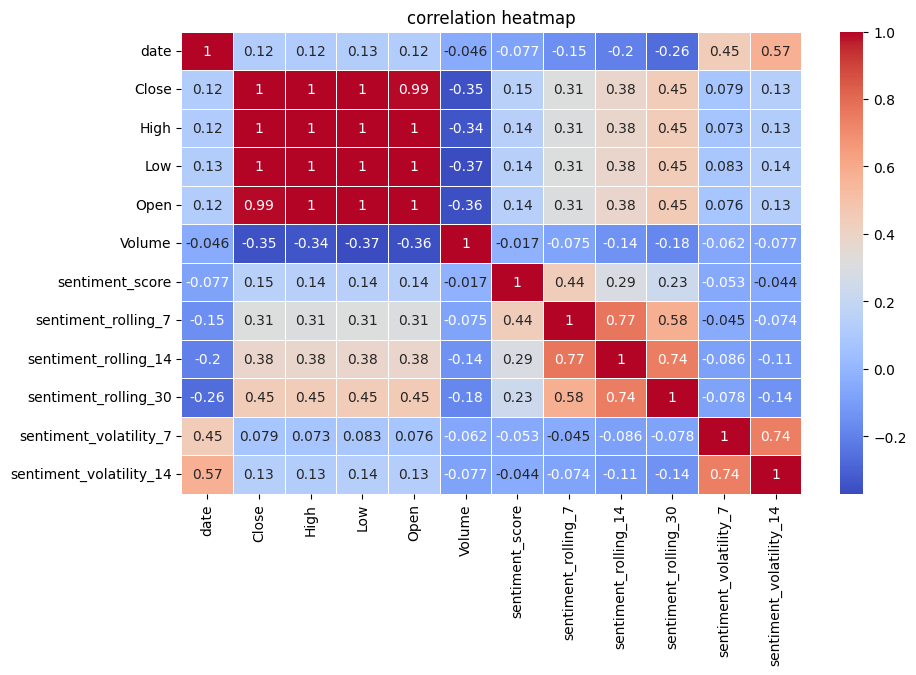

In [185]:
correlation_matrix = final_data.corr()
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('correlation heatmap')
plt.show()

As we can see in the new correlation heatmap, some of the new features are good predictors. I set a threshold as ±0.15 and select features above it. The Threshold is set to 0.15 to capture the sentiment score because usually, the sentiment score has a low correlation to the target variable, but it still impacts stock price in indirect ways.

In [186]:
final_data = final_data[['Close', 'Open', 'Low', 'High', 'Volume', 'sentiment_rolling_7', 'sentiment_rolling_14', 'sentiment_rolling_30', 'sentiment_score']]
final_data.head()

,Close,Open,Low,High,Volume,sentiment_rolling_7,sentiment_rolling_14,sentiment_rolling_30,sentiment_score
0,310.416656,311.736664,301.666656,314.566681,73138200.0,-0.05598,-0.056158,-0.056577,0.191575
1,301.886658,309.393341,296.470001,310.500000,66792900.0,-0.05598,-0.056158,-0.056577,0.142081
2,297.046661,294.000000,293.506653,312.333344,78855600.0,-0.05598,-0.056158,-0.056577,-0.011418
3,307.773346,299.073334,293.723328,312.166656,73625400.0,-0.05598,-0.056158,-0.056577,-0.115670
4,302.446655,307.929993,300.903320,315.923340,60994500.0,-0.05598,-0.056158,-0.056577,-0.126334


In [187]:
final_data.describe()

,Close,Open,Low,High,Volume,sentiment_rolling_7,sentiment_rolling_14,sentiment_rolling_30,sentiment_score
count,770.000000,770.000000,770.000000,770.000000,7.700000e+02,770.000000,770.000000,770.000000,770.000000
mean,241.478515,241.736797,235.971671,247.093507,1.052512e+08,-0.055980,-0.056158,-0.056577,-0.055827
std,66.254905,66.620318,64.626087,68.072756,3.969691e+07,0.106030,0.081007,0.060044,0.227593
min,108.099998,103.000000,101.809998,111.750000,3.716760e+07,-0.364670,-0.279075,-0.235802,-0.928341
25%,190.999996,190.575005,186.032497,195.769997,7.610340e+07,-0.123327,-0.108117,-0.096573,-0.199639
50%,235.260002,234.120003,230.221672,239.528336,9.797160e+07,-0.054445,-0.054167,-0.057788,-0.046830
75%,273.245827,274.218330,266.924995,279.332512,1.249970e+08,0.018986,-0.006951,-0.011565,0.095145
max,479.859985,475.899994,457.510010,488.540009,3.065906e+08,0.271640,0.174966,0.072914,0.643566


In [188]:
# save the final dataset to use in the model development phase
final_data.to_csv('/content/drive/MyDrive/Colab Notebooks/final_project/final_dataset.csv')

In [189]:
final_data.head()

,Close,Open,Low,High,Volume,sentiment_rolling_7,sentiment_rolling_14,sentiment_rolling_30,sentiment_score
0,310.416656,311.736664,301.666656,314.566681,73138200.0,-0.05598,-0.056158,-0.056577,0.191575
1,301.886658,309.393341,296.470001,310.500000,66792900.0,-0.05598,-0.056158,-0.056577,0.142081
2,297.046661,294.000000,293.506653,312.333344,78855600.0,-0.05598,-0.056158,-0.056577,-0.011418
3,307.773346,299.073334,293.723328,312.166656,73625400.0,-0.05598,-0.056158,-0.056577,-0.115670
4,302.446655,307.929993,300.903320,315.923340,60994500.0,-0.05598,-0.056158,-0.056577,-0.126334
